<a href="https://colab.research.google.com/github/aldisleepyhead666/UTS-Analisis-Dan-Visualisasi/blob/main/HRemployeepP6ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

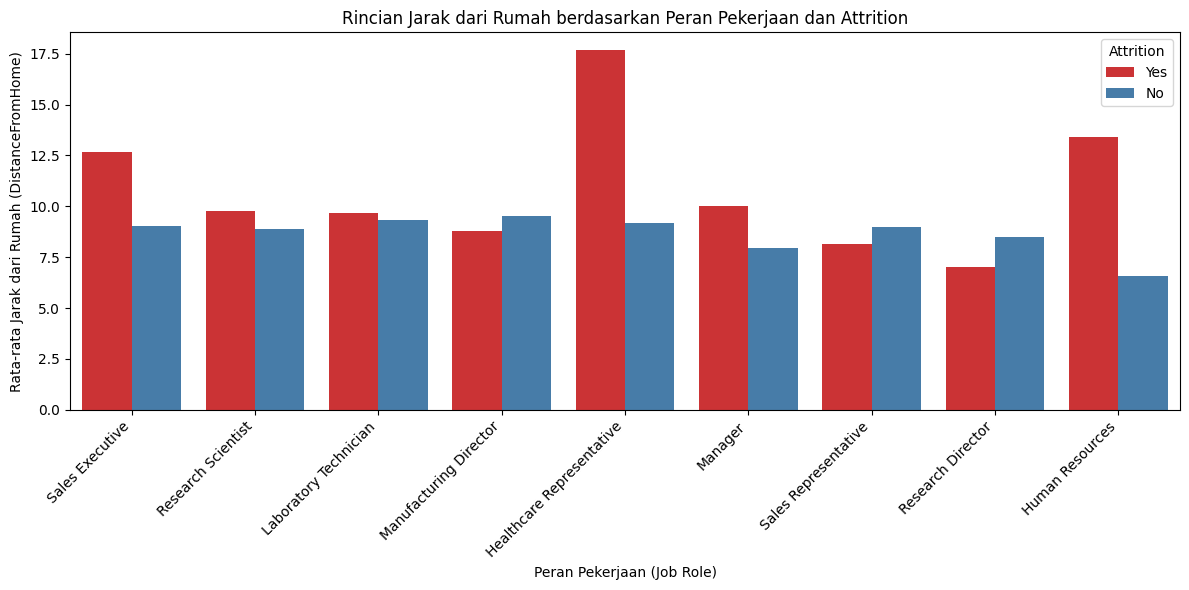

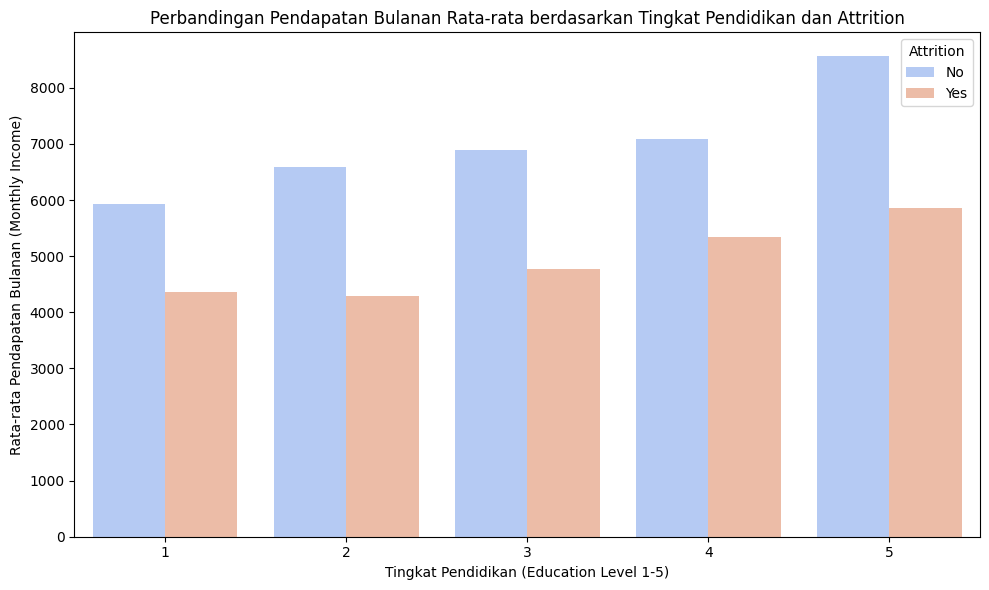

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca dataset IBM Attrition
df_hr = pd.read_csv('HR-Employee-Attrition.csv')

# 2. Menampilkan informasi dasar data
print("--- Info Dataset ---")
print(df_hr.info())
print("\n--- Pengecekan Data Kosong ---")
print(df_hr.isnull().sum().sum())

# 3. Grafik 1: Jarak dari Rumah berdasarkan Peran Kerja & Attrition
plt.figure(figsize=(12, 6))
sns.barplot(data=df_hr, x='JobRole', y='DistanceFromHome', hue='Attrition', palette='Set1', errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Rincian Jarak dari Rumah berdasarkan Peran Pekerjaan dan Attrition')
plt.xlabel('Peran Pekerjaan (Job Role)')
plt.ylabel('Rata-rata Jarak dari Rumah (DistanceFromHome)')
plt.tight_layout()
plt.show()

# 4. Grafik 2: Pendapatan Bulanan berdasarkan Pendidikan & Attrition
plt.figure(figsize=(10, 6))
sns.barplot(data=df_hr, x='Education', y='MonthlyIncome', hue='Attrition', palette='coolwarm', errorbar=None)
plt.title('Perbandingan Pendapatan Bulanan Rata-rata berdasarkan Tingkat Pendidikan dan Attrition')
plt.xlabel('Tingkat Pendidikan (Education Level 1-5)')
plt.ylabel('Rata-rata Pendapatan Bulanan (Monthly Income)')
plt.tight_layout()
plt.show()

In [16]:
# 1. Mengubah target Attrition (Yes/No) menjadi biner angka (1/0)
df_hr['Attrition_Code'] = df_hr['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. One-Hot Encoding untuk fitur teks/kategorikal penting
fitur_kategorikal = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
df_ml = pd.get_dummies(df_hr, columns=fitur_kategorikal, drop_first=True)

# 3. Menghapus kolom teks asli dan kolom ID yang tidak memberikan informasi pola
kolom_hapus = ['Attrition', 'Over18', 'StandardHours', 'EmployeeCount', 'EmployeeNumber']
df_ml = df_ml.drop(columns=kolom_hapus)

print("Ukuran dataset setelah dilakukan Feature Engineering & Encoding:", df_ml.shape)

Ukuran dataset setelah dilakukan Feature Engineering & Encoding: (1470, 45)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. Memisahkan Fitur (X) dan Target (y)
X = df_ml.drop(columns=['Attrition_Code'])
y = df_ml['Attrition_Code']

# 2. Membagi Data Training dan Testing (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Membangun dan Melatih Model Random Forest
model_hr = RandomForestClassifier(n_estimators=100, random_state=42)
model_hr.fit(X_train, y_train)

# 4. Mendapatkan 5 Faktor Utama Penyebab Karyawan Keluar
importances = model_hr.feature_importances_
indeks_fitur = np.argsort(importances)[::-1]

print("--- 5 FAKTOR UTAMA PENYEBAB KARYAWAN RESIGN ---")
for i in range(5):
    print(f"{i+1}. {X.columns[indeks_fitur[i]]} (Skor Pengaruh: {importances[indeks_fitur[i]]:.4f})")

--- 5 FAKTOR UTAMA PENYEBAB KARYAWAN RESIGN ---
1. MonthlyIncome (Skor Pengaruh: 0.0794)
2. OverTime_Yes (Skor Pengaruh: 0.0589)
3. Age (Skor Pengaruh: 0.0561)
4. DailyRate (Skor Pengaruh: 0.0515)
5. MonthlyRate (Skor Pengaruh: 0.0489)
